### 0. Requirements

run once

In [5]:
pip install pandas numpy matplotlib seaborn scikit-learn torch torchvision torchaudio transformers datasets accelerate tqdm


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Importing necessary libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
import os
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    AutoTokenizer, 
    AutoModelForSequenceClassification
)


c:\Users\PC MOD NEPAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))



True
1
NVIDIA GeForce RTX 3060 Ti


In [27]:
import sys
print(sys.executable)


c:\Users\PC MOD NEPAL\AppData\Local\Programs\Python\Python312\python.exe


In [8]:
def get_device_and_config():
    config = {}

    # CUDA GPU
    if torch.cuda.is_available():
        device = torch.device("cuda")
        backend = "CUDA GPU"

        config.update({
            "per_device_train_batch_size": 32,
            "per_device_eval_batch_size": 32,
            "fp16": True,
            "gradient_accumulation_steps": 1
        })

    # Apple Silicon (MPS)
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        backend = "Apple Silicon (MPS)"

        config.update({
            "per_device_train_batch_size": 16,
            "per_device_eval_batch_size": 16,
            "fp16": False,   # unstable on MPS
            "gradient_accumulation_steps": 1
        })

    # TPU (XLA)
    elif "COLAB_TPU_ADDR" in os.environ:
        import torch_xla.core.xla_model as xm
        device = xm.xla_device()
        backend = "TPU"

        config.update({
            "per_device_train_batch_size": 32,
            "per_device_eval_batch_size": 32,
            "fp16": False,
            "gradient_accumulation_steps": 2
        })

    # CPU fallback
    else:
        device = torch.device("cpu")
        backend = "CPU"

        config.update({
            "per_device_train_batch_size": 8,
            "per_device_eval_batch_size": 8,
            "fp16": False,
            "gradient_accumulation_steps": 2
        })

    return device, backend, config


device, backend, perf_config = get_device_and_config()
print(f"Device detected: {backend}")
print("Auto performance config:", perf_config)

Device detected: CUDA GPU
Auto performance config: {'per_device_train_batch_size': 32, 'per_device_eval_batch_size': 32, 'fp16': True, 'gradient_accumulation_steps': 1}


### 2. Read the dataset

In [9]:
df = pd.read_csv("combined_ai_human.csv")

df.head()


,text,generated
0,# The Human Toll of Nuclear Testing: A Legacy ...,1
1,"**Title: In the Age of Coronavirus, the Only W...",1
2,"**Roberta Karmel, First Woman Named to the S.E...",1
3,"**Summer Reading Contest, Week 2: What Got You...",1
4,**Title: The Spectacle Returns: A Record-Break...,1


In [10]:
print(df.info())
print(df['generated'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44552 entries, 0 to 44551
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       44552 non-null  object
 1   generated  44552 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 696.3+ KB
None
generated
0    22820
1    21732
Name: count, dtype: int64


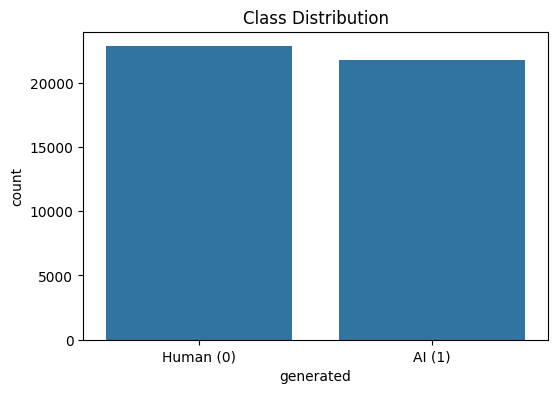

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='generated', data=df)
plt.xticks([0,1], ['Human (0)', 'AI (1)'])
plt.title("Class Distribution")
plt.show()


### 3. Text length Analysis

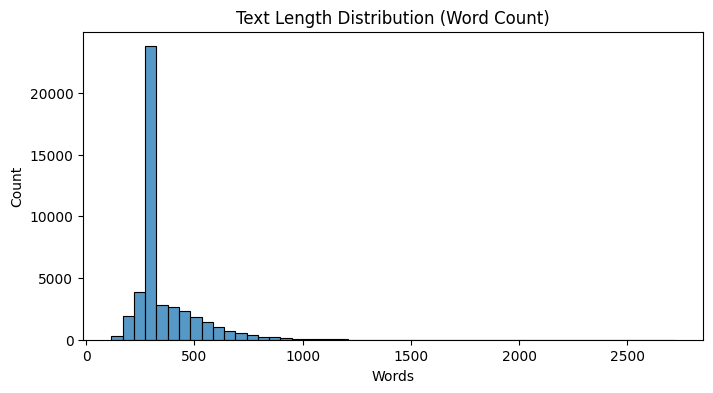

In [12]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,4))
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution (Word Count)")
plt.xlabel("Words")
plt.show()


### 4. Train and Validation splitting

In [13]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'],
    df['generated'],
    test_size=0.2, # 80 to 20 split
    stratify=df['generated'], # keeps the proportion same
    random_state=42
)


### 5. Loading BERT tokenizer

In [14]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")


### 6. Tokenize the text column

In [15]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True, # cuts long texts
    padding=True, # equal sequence length
    max_length=300 # max length is 300 as previously done in preprocessing
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=300
)


### 7. Custom pytorch dataset
This wraps tokenized data into a format Hugging Face Trainer understands.

In [16]:
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)


### 8. Create Dataset Objects
Creates training and validation datasets for the model.

In [17]:
train_dataset = TextDataset(train_encodings, train_labels)
val_dataset = TextDataset(val_encodings, val_labels)


### 9. Load BERT model


In [18]:
# model = BertForSequenceClassification.from_pretrained(
#     "bert-base-uncased",
#     num_labels=2 # Human vs AI
# )

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.to(device)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1342.71it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


### 10. Training Arguments

In [19]:
training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    num_train_epochs=3,
    weight_decay=0.01,

    logging_dir="./logs",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    report_to="none",

    # Auto-detected performance settings
    per_device_train_batch_size=perf_config["per_device_train_batch_size"],
    per_device_eval_batch_size=perf_config["per_device_eval_batch_size"],
    fp16=perf_config["fp16"],
    gradient_accumulation_steps=perf_config["gradient_accumulation_steps"],
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [20]:
# training_args = TrainingArguments(
#     output_dir="./results",
#     evaluation_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=2e-5, # Standard BERT learning rate is 2e-5
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     num_train_epochs=3,
#     weight_decay=0.01,
#     logging_dir="./logs",
#     load_best_model_at_end=True, # tries to avoid overfitting
#     metric_for_best_model="eval_loss"
# )

# training_args = TrainingArguments(
#     output_dir="./results",
#     evaluation_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=2e-5, # Standard BERT learning rate is 2e-5
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     num_train_epochs=3,
#     weight_decay=0.01,
#     logging_dir="./logs",
#     logging_steps=100,
#     load_best_model_at_end=True, # tries to avoid overfitting
#     metric_for_best_model="f1",
#     report_to="none"
# )

In [21]:
model.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


### 11. Define trainer
Hugging Face Trainer handles: training loop, evaluation and checkpointing

In [22]:
# Shows precision, recall, F1-score
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [24]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)


### 12. Train the model

In [25]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.003408,0.001545,0.999776,0.999770,0.999770,0.999770
2,0.000038,0.001774,0.999776,0.999770,0.999770,0.999770
3,0.000023,0.001888,0.999776,0.999770,0.999770,0.999770


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.71it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3342, training_loss=0.004706058477474163, metrics={'train_runtime': 519.2162, 'train_samples_per_second': 205.932, 'train_steps_per_second': 6.437, 'total_flos': 8299108398337200.0, 'train_loss': 0.004706058477474163, 'epoch': 3.0})

### 13. Evaluation

In [26]:
preds = trainer.predict(val_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

print(classification_report(val_labels, y_pred)) 

# Converts logits → class predictions

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4564
           1       1.00      1.00      1.00      4347

    accuracy                           1.00      8911
   macro avg       1.00      1.00      1.00      8911
weighted avg       1.00      1.00      1.00      8911



In [27]:
eval_results = trainer.evaluate()
print(eval_results)

{'eval_loss': 0.001544944941997528, 'eval_accuracy': 0.9997755582987319, 'eval_precision': 0.9997699562916954, 'eval_recall': 0.9997699562916954, 'eval_f1': 0.9997699562916954, 'eval_runtime': 11.3322, 'eval_samples_per_second': 786.344, 'eval_steps_per_second': 24.62, 'epoch': 3.0}


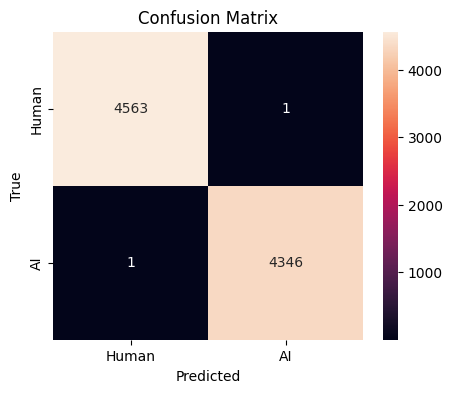

In [28]:
cm = confusion_matrix(val_labels, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Human", "AI"],
            yticklabels=["Human", "AI"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


### 14. Saving the model


In [29]:
trainer.save_model("./bert_ai_human_detector")
tokenizer.save_pretrained("./bert_ai_human_detector")


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.36it/s]


('./bert_ai_human_detector\\tokenizer_config.json',
 './bert_ai_human_detector\\tokenizer.json')